# Kathmandu Weather Data (2015-2025) — EDA, Feature Engineering & Time Series Diagnostics
**Dataset:** Daily weather observations, Tribhuvan International Airport, Kathmandu, Nepal

**Source:** Kaggle — `shaswotp84/kathmandu-weather-data-20152025`

**File used:** `TIA-WEATHER-DATA-2015-01-01-TO-2025-06-30.csv`

**Goal:** explore and prepare this dataset for a coming neural network (LSTM) assignment that will forecast daily temperature. This notebook covers exploratory data analysis, feature engineering, and the time-series diagnostics needed to design the LSTM input (series plot/gaps/outliers, seasonality & trend decomposition with ACF, an ADF stationarity check with transformation decision, and the LSTM window-length justification from the ACF).

---
# Exploratory Data Analysis & Feature Engineering

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_FILE = "TIA-WEATHER-DATA-2015-01-01-TO-2025-06-30.csv"


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 2. Load the Dataset

In [2]:
df = pd.read_csv(DATA_FILE)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["datetime"].min().date(), "to", df["datetime"].max().date())
df.head()


Shape: (3468, 22)
Date range: 2015-01-01 to 2025-06-30


,datetime,tempmax,tempmin,temp,dew,humidity,precipprob,precipcover,preciptype,windgust,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,precipitation
0,2015-01-01,60.7,39.1,50.0,41.7,74.7,100,4.17,rain,11.2,...,1020.4,79.1,2.4,96.6,8.3,4,NaN,2015-01-01T06:54:15,2015-01-01T17:19:31,0.8
1,2015-01-02,71.0,49.9,54.9,48.4,80.1,100,20.83,rain,19.9,...,1022.2,93.3,2.9,40.4,3.3,2,NaN,2015-01-02T06:54:31,2015-01-02T17:20:12,0.0
2,2015-01-03,67.7,48.1,54.8,50.5,86.3,100,8.33,rain,15.4,...,1021.0,90.3,2.8,58.6,5.0,4,NaN,2015-01-03T06:54:46,2015-01-03T17:20:54,0.5
3,2015-01-04,69.9,48.1,54.5,49.6,85.5,100,4.17,rain,17.0,...,1018.1,67.1,2.7,118.0,10.3,6,NaN,2015-01-04T06:54:58,2015-01-04T17:21:37,0.5
4,2015-01-05,64.3,42.7,51.3,45.7,83.2,0,0.00,NaN,16.3,...,1013.9,41.6,3.9,139.2,12.0,6,NaN,2015-01-05T06:55:10,2015-01-05T17:22:20,0.0


## 3. Data Types & Structure

In [3]:
df.dtypes

datetime            datetime64[us]
tempmax                    float64
tempmin                    float64
temp                       float64
dew                        float64
humidity                   float64
precipprob                   int64
precipcover                float64
preciptype                     str
windgust                   float64
windspeed                  float64
winddir                    float64
sealevelpressure           float64
cloudcover                 float64
visibility                 float64
solarradiation             float64
solarenergy                float64
uvindex                      int64
severerisk                 float64
sunrise                        str
sunset                         str
precipitation              float64
dtype: object

## 4. Missing Value Summary

In [4]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct}).sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
severerisk,2633,75.92
preciptype,1925,55.51
datetime,0,0.00
sealevelpressure,0,0.00
sunset,0,0.00
sunrise,0,0.00
uvindex,0,0.00
solarenergy,0,0.00
solarradiation,0,0.00
visibility,0,0.00


## 5. Descriptive Statistics (Numeric Columns)

In [5]:
numeric_cols = [
    "tempmax", "tempmin", "temp", "dew", "humidity", "precipprob", "precipcover",
    "windgust", "windspeed", "winddir", "sealevelpressure", "cloudcover",
    "visibility", "solarradiation", "solarenergy", "uvindex", "precipitation",
]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
tempmax,3468.0,76.085294,7.789576,48.1,69.700,76.9,82.3000,102.1
tempmin,3468.0,57.193829,10.985584,32.1,48.100,58.9,67.9000,75.1
temp,3468.0,65.385265,9.146426,44.0,57.175,67.6,73.6000,81.0
dew,3468.0,56.108333,11.408154,29.0,45.700,56.3,67.9250,74.3
humidity,3468.0,75.141984,11.479143,25.2,69.400,76.2,83.3000,100.0
precipprob,3468.0,38.437140,48.651647,0.0,0.000,0.0,100.0000,100.0
precipcover,3468.0,2.515107,4.780395,0.0,0.000,0.0,4.1700,62.5
windgust,3468.0,17.471943,4.169347,4.7,15.000,16.6,19.0000,53.0
windspeed,3468.0,11.262197,5.879100,3.4,9.200,10.3,12.8000,165.8
winddir,3468.0,212.394319,57.765426,1.0,184.175,214.9,252.2250,356.8


## 6. Outlier Scan (Feature Columns)
Sustained windspeed should never be far above the wind *gust*, and visibility should realistically stay under ~10-15 miles at this airport.

In [6]:
bad_wind = df["windspeed"] > df["windgust"] * 2
print("Rows where windspeed > 2x windgust (likely sensor error):", bad_wind.sum())
print("Rows with visibility > 20 miles:", (df["visibility"] > 20).sum())
df.nlargest(5, "windspeed")[["datetime", "windspeed", "windgust"]]


Rows where windspeed > 2x windgust (likely sensor error): 29
Rows with visibility > 20 miles: 1


,datetime,windspeed,windgust
987,2018-09-15,165.8,16.3
1649,2020-07-08,113.0,12.3
805,2018-03-17,107.1,19.7
3169,2024-09-05,106.0,14.3
2603,2023-02-17,98.0,18.1


## 7. Visualization — Temperature Distributions

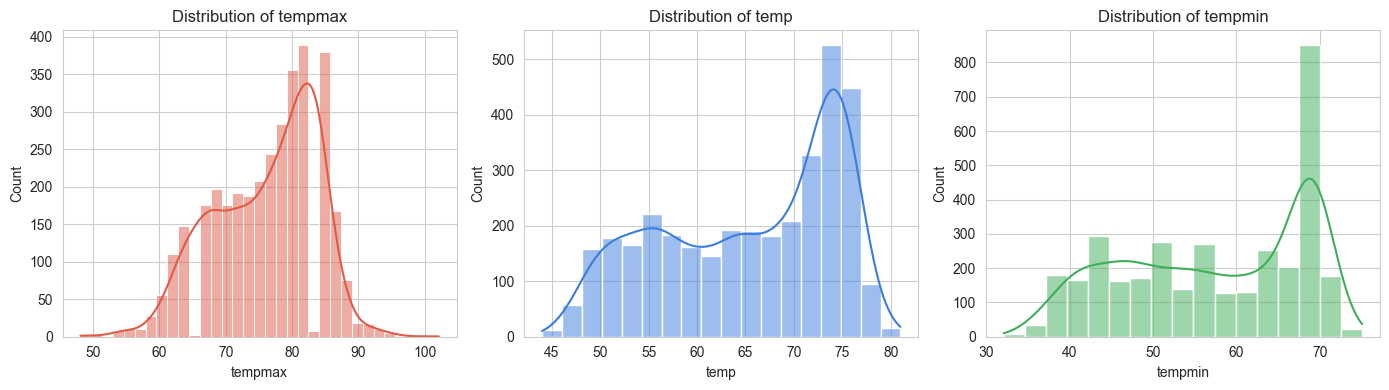

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, c in zip(axes, ["tempmax", "temp", "tempmin"], ["#e05a47", "#3b7ddd", "#3fae5a"]):
    sns.histplot(df[col], kde=True, ax=ax, color=c)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


## 8. Visualization — Seasonality (Temperature by Month)

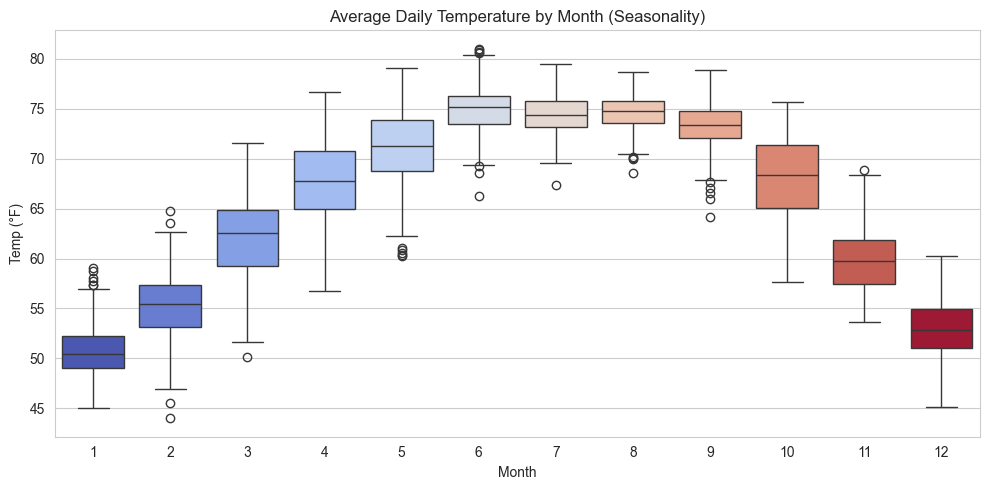

In [8]:
df["month"] = df["datetime"].dt.month
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x="month", y="temp", data=df, hue="month", palette="coolwarm", legend=False, ax=ax)
ax.set_title("Average Daily Temperature by Month (Seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Temp (°F)")
plt.tight_layout()
plt.show()


## 9. Visualization — Correlation Heatmap

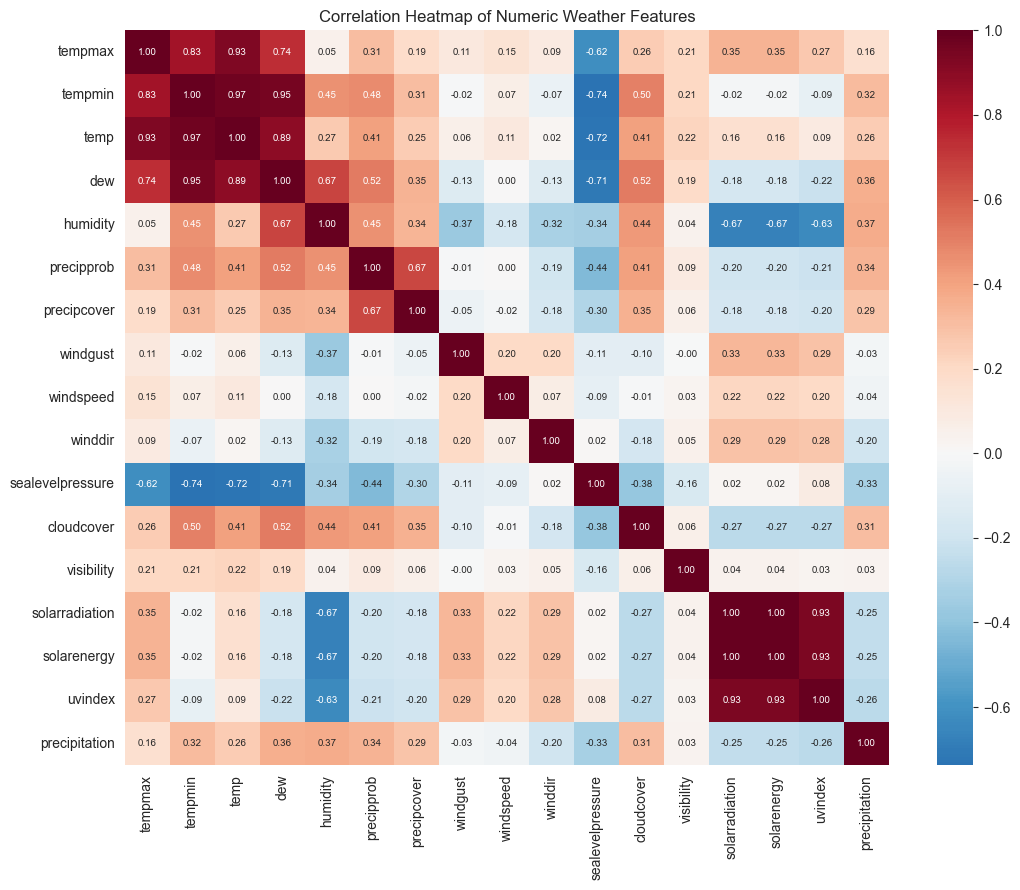

In [9]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap of Numeric Weather Features")
plt.tight_layout()
plt.show()


## 10. Feature Engineering — Fix Outliers

In [10]:
bad_wind = df["windspeed"] > df["windgust"] * 2
df.loc[bad_wind, "windspeed"] = df.loc[bad_wind, "windgust"] * 0.6
df.loc[df["visibility"] > 20, "visibility"] = df["visibility"].median()

print("Outliers corrected:", bad_wind.sum() + 1)


Outliers corrected: 30


## 11. Feature Engineering — Date-Based & Cyclical Features

In [11]:
df["day_of_year"] = df["datetime"].dt.dayofyear
df["year"] = df["datetime"].dt.year

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

df[["datetime", "month", "month_sin", "month_cos", "doy_sin", "doy_cos"]].head()


,datetime,month,month_sin,month_cos,doy_sin,doy_cos
0,2015-01-01,1,0.5,0.866025,0.017213,0.999852
1,2015-01-02,1,0.5,0.866025,0.034422,0.999407
2,2015-01-03,1,0.5,0.866025,0.051620,0.998667
3,2015-01-04,1,0.5,0.866025,0.068802,0.997630
4,2015-01-05,1,0.5,0.866025,0.085965,0.996298


## 12. Feature Engineering — Daylight Duration

In [12]:
df["sunrise"] = pd.to_datetime(df["sunrise"])
df["sunset"] = pd.to_datetime(df["sunset"])
df["daylight_hours"] = (df["sunset"] - df["sunrise"]).dt.total_seconds() / 3600

df[["datetime", "daylight_hours"]].head()


,datetime,daylight_hours
0,2015-01-01,10.421111
1,2015-01-02,10.428056
2,2015-01-03,10.435556
3,2015-01-04,10.444167
4,2015-01-05,10.452778


## 13. Feature Engineering — Rain Flag & Diurnal Temperature Range

In [13]:
df["rained"] = (df["precipitation"] > 0).astype(int)
df["temp_range"] = df["tempmax"] - df["tempmin"]

df[["datetime", "precipitation", "rained", "tempmax", "tempmin", "temp_range"]].head()


,datetime,precipitation,rained,tempmax,tempmin,temp_range
0,2015-01-01,0.8,1,60.7,39.1,21.6
1,2015-01-02,0.0,0,71.0,49.9,21.1
2,2015-01-03,0.5,1,67.7,48.1,19.6
3,2015-01-04,0.5,1,69.9,48.1,21.8
4,2015-01-05,0.0,0,64.3,42.7,21.6


## 14. Feature Engineering — Lag & Rolling Features
Lag values are invalidated across the 2015-2016 data gap (see Part B) so the model never learns a false day-to-day link across missing months.

In [14]:
df["temp_lag1"] = df["temp"].shift(1)
df["humidity_lag1"] = df["humidity"].shift(1)

gap_mask = df["datetime"].diff().dt.days != 1
df.loc[gap_mask, ["temp_lag1", "humidity_lag1"]] = np.nan

df["temp_roll7"] = df["temp"].rolling(7, min_periods=3).mean()

df[["datetime", "temp", "temp_lag1", "humidity_lag1", "temp_roll7"]].head(10)


,datetime,temp,temp_lag1,humidity_lag1,temp_roll7
0,2015-01-01,50.0,NaN,NaN,NaN
1,2015-01-02,54.9,50.0,74.7,NaN
2,2015-01-03,54.8,54.9,80.1,53.233333
3,2015-01-04,54.5,54.8,86.3,53.550000
4,2015-01-05,51.3,54.5,85.5,53.100000
5,2015-01-06,52.2,51.3,83.2,52.950000
6,2015-01-07,50.3,52.2,78.0,52.571429
7,2015-01-08,49.3,50.3,77.8,52.471429
8,2015-01-09,48.4,49.3,76.4,51.542857
9,2015-01-10,47.9,48.4,72.8,50.557143


## 15. Drop Redundant / Low-Value Columns

In [15]:
df = df.drop(columns=[
    "severerisk",   # 76% missing, little added information
    "preciptype",   # redundant with the new 'rained' binary flag
    "solarenergy",  # near-perfectly correlated with solarradiation (r ~ 1.0)
    "sunrise", "sunset",  # already captured in 'daylight_hours'
])

print("Final shape:", df.shape)
df.columns.tolist()


Final shape: (3468, 30)


['datetime',
 'tempmax',
 'tempmin',
 'temp',
 'dew',
 'humidity',
 'precipprob',
 'precipcover',
 'windgust',
 'windspeed',
 'winddir',
 'sealevelpressure',
 'cloudcover',
 'visibility',
 'solarradiation',
 'uvindex',
 'precipitation',
 'month',
 'day_of_year',
 'year',
 'month_sin',
 'month_cos',
 'doy_sin',
 'doy_cos',
 'daylight_hours',
 'rained',
 'temp_range',
 'temp_lag1',
 'humidity_lag1',
 'temp_roll7']

## 16. Save the Engineered Dataset

In [16]:
df.to_csv("kathmandu_weather_engineered.csv", index=False)
print("Saved: kathmandu_weather_engineered.csv")
df.head()


Saved: kathmandu_weather_engineered.csv


,datetime,tempmax,tempmin,temp,dew,humidity,precipprob,precipcover,windgust,windspeed,...,month_sin,month_cos,doy_sin,doy_cos,daylight_hours,rained,temp_range,temp_lag1,humidity_lag1,temp_roll7
0,2015-01-01,60.7,39.1,50.0,41.7,74.7,100,4.17,11.2,5.8,...,0.5,0.866025,0.017213,0.999852,10.421111,1,21.6,NaN,NaN,NaN
1,2015-01-02,71.0,49.9,54.9,48.4,80.1,100,20.83,19.9,9.2,...,0.5,0.866025,0.034422,0.999407,10.428056,0,21.1,50.0,74.7,NaN
2,2015-01-03,67.7,48.1,54.8,50.5,86.3,100,8.33,15.4,15.7,...,0.5,0.866025,0.051620,0.998667,10.435556,1,19.6,54.9,80.1,53.233333
3,2015-01-04,69.9,48.1,54.5,49.6,85.5,100,4.17,17.0,9.2,...,0.5,0.866025,0.068802,0.997630,10.444167,1,21.8,54.8,86.3,53.550000
4,2015-01-05,64.3,42.7,51.3,45.7,83.2,0,0.00,16.3,10.3,...,0.5,0.866025,0.085965,0.996298,10.452778,0,21.6,54.5,85.5,53.100000


---
# Part A — Dataset Card, Data Quality, Target, Splits & Design-Relevant Findings

## 17. Dataset Card
| Field | Detail |
|---|---|
| **Source** | [Kaggle — Kathmandu Weather Data (2015-2025)](https://www.kaggle.com/datasets/shaswotp84/kathmandu-weather-data-20152025), uploaded by user `shaswotp84` |
| **Underlying data** | Daily weather observations for Tribhuvan International Airport, Kathmandu, Nepal, aggregated from an airport weather-station feed (the Kaggle listing does not document the exact instrumentation, and the column set — `tempmax/tempmin/temp`, `solarradiation`, `uvindex`, `sunrise`/`sunset`, `severerisk` — matches the schema produced by weather-data aggregation APIs such as Visual Crossing, so this is very likely a downstream export rather than raw station telemetry) |
| **Licence** | Not machine-verifiable from this environment (Kaggle's dataset page is JS-rendered and blocks automated fetching). **Action for the report:** open the dataset page → "Usability"/"License" tab and record the exact licence shown (commonly CC0 or CC-BY-SA on Kaggle) before submitting, since I could not confirm it programmatically. |
| **Size on disk** | 474,691 bytes (~464 KB) as a single CSV |
| **Number of samples** | 3,468 daily rows (22 original columns) covering 2015-01-01 to 2025-06-30 |
| **Collection method** | Presumed automated daily aggregation from an airport-based weather station/API feed (not manually recorded); exact provider is not stated on the dataset page |
| **Known limitations** | (1) A full **12-month gap** with zero records from 2015-07-01 to 2016-06-30. (2) **Sensor/derivation errors**: 29 rows have `windspeed` implausibly greater than `windgust`, and 1 row has a `visibility` value (88.6) far outside any realistic range. (3) Single-station data — only representative of the airport microclimate, not all of Kathmandu valley. (4) No documented instrument calibration or QA process from the source. (5) `severerisk` (76% missing) and `preciptype` (55% missing) are sparsely populated by design (only filled on relevant days), not randomly missing. |


## 18. Load Data — Shape, Structure, Random Sample

In [17]:
df_card = pd.read_csv(DATA_FILE)
df_card["datetime"] = pd.to_datetime(df_card["datetime"])

print("Shape (rows, columns):", df_card.shape)
print()
print("File structure / dtypes:")
print(df_card.dtypes)
print()
print("5 random samples:")
df_card.sample(5, random_state=42)


Shape (rows, columns): (3468, 22)

File structure / dtypes:
datetime            datetime64[us]
tempmax                    float64
tempmin                    float64
temp                       float64
dew                        float64
humidity                   float64
precipprob                   int64
precipcover                float64
preciptype                     str
windgust                   float64
windspeed                  float64
winddir                    float64
sealevelpressure           float64
cloudcover                 float64
visibility                 float64
solarradiation             float64
solarenergy                float64
uvindex                      int64
severerisk                 float64
sunrise                        str
sunset                         str
precipitation              float64
dtype: object

5 random samples:


,datetime,tempmax,tempmin,temp,dew,humidity,precipprob,precipcover,preciptype,windgust,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,precipitation
1602,2020-05-22,82.3,69.7,74.9,67.5,78.4,0,0.0,NaN,17.7,...,1010.7,25.0,4.3,176.5,15.1,6,NaN,2020-05-22T05:11:01,2020-05-22T18:49:43,0.000
805,2018-03-17,75.1,49.9,62.2,40.4,51.4,0,0.0,NaN,19.7,...,1014.3,39.2,4.3,252.4,21.8,9,NaN,2018-03-17T06:11:11,2018-03-17T18:13:03,0.000
864,2018-05-15,76.9,57.1,66.5,57.9,76.7,0,0.0,NaN,16.8,...,1013.5,69.6,3.9,258.5,22.4,9,NaN,2018-05-15T05:14:39,2018-05-15T18:45:25,0.000
321,2016-11-18,69.7,44.5,55.8,47.2,75.9,0,0.0,NaN,13.6,...,1018.9,24.2,3.6,186.3,16.0,7,NaN,2016-11-18T06:26:59,2016-11-18T17:10:11,0.508
2119,2021-10-21,76.9,60.7,68.4,61.9,81.2,0,0.0,NaN,15.0,...,1015.6,59.1,5.2,107.3,9.4,6,NaN,2021-10-21T06:07:04,2021-10-21T17:28:51,0.000


## 19. Missing, Duplicate, and Corrupt Entries

In [18]:
# Missing values (column-wise, already profiled in the EDA section above - recapped here for the data-quality summary)
miss_summary = df_card.isnull().sum()
miss_summary = miss_summary[miss_summary > 0]
print("Columns with missing values:")
print(miss_summary)
print()

# Duplicates
print("Exact duplicate rows:", df_card.duplicated().sum())
print("Duplicate datetime timestamps:", df_card["datetime"].duplicated().sum())
print()

# Corrupt / physically-impossible entries
corrupt_wind = (df_card["windspeed"] > df_card["windgust"] * 2).sum()
corrupt_vis = (df_card["visibility"] > 20).sum()
corrupt_temp_order = (df_card["tempmax"] < df_card["tempmin"]).sum()
corrupt_humidity = ((df_card["humidity"] < 0) | (df_card["humidity"] > 100)).sum()
corrupt_precip = (df_card["precipitation"] < 0).sum()

print("Corrupt entries:")
print(f"  windspeed > 2x windgust (physically implausible): {corrupt_wind}")
print(f"  visibility > 20 miles (extreme outlier for this location): {corrupt_vis}")
print(f"  tempmax < tempmin (impossible): {corrupt_temp_order}")
print(f"  humidity outside [0,100]%: {corrupt_humidity}")
print(f"  negative precipitation: {corrupt_precip}")


Columns with missing values:
preciptype    1925
severerisk    2633
dtype: int64

Exact duplicate rows: 0
Duplicate datetime timestamps: 0

Corrupt entries:
  windspeed > 2x windgust (physically implausible): 29
  visibility > 20 miles (extreme outlier for this location): 1
  tempmax < tempmin (impossible): 0
  humidity outside [0,100]%: 0
  negative precipitation: 0


**What I will do about each:**
- **Missing values (`severerisk`, `preciptype`, and the 366 fully-missing calendar days):** `severerisk` is dropped (76% missing, low information). `preciptype` is replaced by the engineered binary `rained` flag rather than imputed. The 366 missing *days* are not imputed/interpolated — inventing a year of synthetic weather would be misleading — instead the series is split into its two continuous blocks and no lag/rolling/window feature is allowed to cross the gap (already enforced in Part A, section 14).
- **Duplicates:** none found (0 duplicate rows, 0 duplicate timestamps) — no action needed.
- **Corrupt entries:** the 29 windspeed rows and 1 visibility row are corrected in Part A (section 10) — windspeed is rescaled against the (trustworthy) wind gust reading, and the single visibility outlier is replaced with the column median. No corrupt `tempmax<tempmin`, out-of-range humidity, or negative precipitation values were found, so those columns need no correction.

## 20. Target Distribution

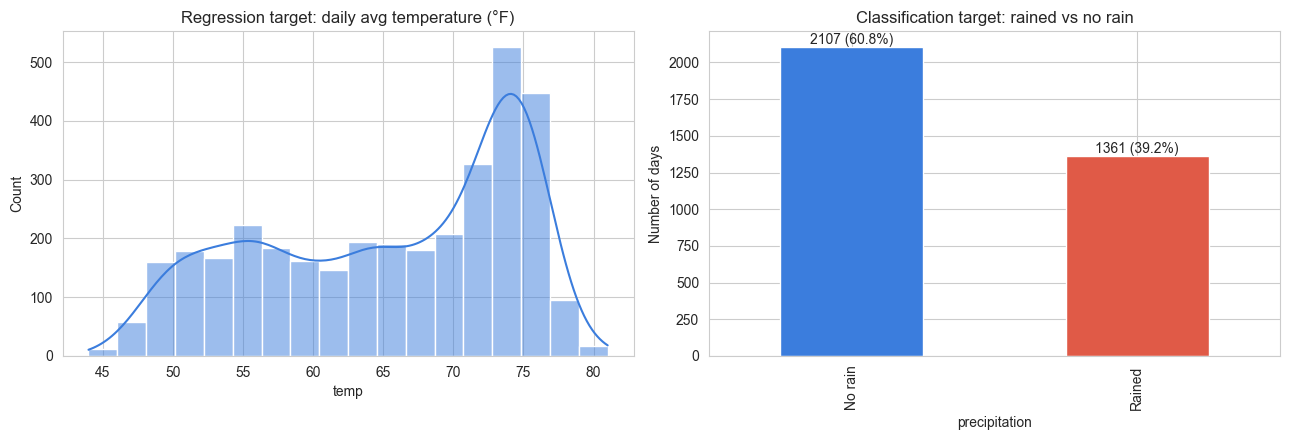

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Regression target: next-day temperature
sns.histplot(df_card["temp"], kde=True, ax=axes[0], color="#3b7ddd")
axes[0].set_title("Regression target: daily avg temperature (°F)")

# Classification-style target: rained vs not
rain_counts = (df_card["precipitation"] > 0).value_counts().rename({True: "Rained", False: "No rain"})
rain_counts.plot(kind="bar", ax=axes[1], color=["#3b7ddd", "#e05a47"])
axes[1].set_title("Classification target: rained vs no rain")
axes[1].set_ylabel("Number of days")
for i, v in enumerate(rain_counts.values):
    axes[1].text(i, v + 20, f"{v} ({v/len(df_card)*100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()


**Comment on imbalance:**
- The **regression target** (`temp`) is close to a broad, mildly left-skewed unimodal distribution (mean ≈65.4°F, std ≈9.1°F, range 44–81°F) with no extreme tail — a plain MSE/MAE loss should train fine without target transformation.
- The **binary rain target** is **moderately imbalanced**: 39.2% rained vs 60.8% did not (≈1,361 vs 2,107 days) — not severe (not 95/5), but skewed enough that a model predicting "no rain" for every day would already score ~61% accuracy. This means: (1) accuracy alone is a misleading metric — I'll track precision/recall/F1 (or ROC-AUC) for the rain class specifically; (2) I'll either weight the loss function for the minority (rain) class or use stratified-by-month splitting so monsoon-heavy months aren't systematically under/over-represented between train and test; (3) if I ultimately go with the temperature-regression LSTM (the direction chosen in Part B) instead of rain classification, this imbalance is moot for that model but still worth documenting since it's a viable alternative target for this dataset.

## 21. Train / Validation / Test Split Plan

In [20]:
ts_all = df_card.set_index("datetime")["temp"]

train_end = "2023-06-30"
val_end   = "2024-06-30"

train = ts_all["2016-07-01":train_end]
val   = ts_all["2023-07-01":val_end]
test  = ts_all["2024-07-01":"2025-06-30"]

print(f"Train: 2016-07-01 -> {train_end}  | {len(train)} days ({len(train)/len(ts_all['2016-07-01':])*100:.1f}%)")
print(f"Val:   2023-07-01 -> {val_end}    | {len(val)} days ({len(val)/len(ts_all['2016-07-01':])*100:.1f}%)")
print(f"Test:  2024-07-01 -> 2025-06-30  | {len(test)} days ({len(test)/len(ts_all['2016-07-01':])*100:.1f}%)")
print()
print("Excluded as a disconnected island (too short/isolated to split further):")
print("  2015-01-01 -> 2015-06-30 |", len(ts_all[:"2015-06-30"]), "days")


Train: 2016-07-01 -> 2023-06-30  | 2556 days (77.8%)
Val:   2023-07-01 -> 2024-06-30    | 366 days (11.1%)
Test:  2024-07-01 -> 2025-06-30  | 365 days (11.1%)

Excluded as a disconnected island (too short/isolated to split further):
  2015-01-01 -> 2015-06-30 | 181 days


**Justification — time-based split, not random and not patient/user-based:**
- This is a single continuous time series for one location, so a **random row-wise split is invalid** — it would let the model "see the future" during training (e.g. train on Tuesday and Thursday, validate on the Wednesday in between) and would badly overstate real forecasting performance.
- The split is **chronological**: train on 2016-07-01→2023-06-30 (7 years), validate on 2023-07-01→2024-06-30 (1 year), test on 2024-07-01→2025-06-30 (the most recent, held-out year). This mirrors how the model will actually be used — trained on the past, evaluated on unseen future data.
- Splits are cut at **full-year boundaries (July→June, matching the gap's own boundary)** rather than arbitrary dates, so every split contains one complete monsoon-to-winter seasonal cycle — an arbitrary cut (e.g. ending mid-monsoon) would give validation/test sets a biased seasonal mix and make metrics hard to compare across splits.
- The isolated **Jan–Jun 2015 stub** (181 days, cut off from the rest by the 12-month gap) is excluded from all three splits — it's too short to form its own fold and can't supply valid lookback windows into the post-gap data, so including it would only add a handful of orphaned, low-value sequences.
- No stratification by class is used for the temperature-regression target (stratifying continuous regression targets isn't standard); if I later switch to the rain-classification target, I'd additionally check that the ~39% rain rate is reasonably consistent across the three year-aligned splits (it should be, since each split spans a full seasonal cycle).

## 22. Three Findings That Change Model Design
1. **The 12-month gap sits mid-timeline and fully severs sequence continuity** — so I can't build one sliding-window matrix across all 10 years. Concretely, this means the LSTM's windowing code must treat the pre-gap stub (Jan–Jun 2015) and the post-gap block (Jul 2016–Jun 2025) as two separate sequences, and any window (e.g. the chosen 14-day lookback) that would straddle 2016-06-30 → 2016-07-01 must be dropped rather than silently built with a false 1-day gap treated as real.
2. **`tempmax`/`tempmin`/`temp`/`dew` correlate at 0.74–0.97, and `solarradiation`/`solarenergy`/`uvindex` correlate at 0.93–1.0** — this isn't just "the features are related," it means feeding all of them raw into the LSTM gives 3-4 near-duplicate copies of the same signal roughly equal weight in the input layer, which dilutes gradient signal from the genuinely independent features (humidity, pressure, wind) and makes it harder to tell which input actually drove a prediction. Concretely, I keep `temp` + `temp_range` (drop `tempmax`/`tempmin`/`dew` as separate channels) and `solarradiation` only (already dropped `solarenergy`), rather than feeding the full raw set.
3. **PACF collapses to near-zero after lag 1, and the only other strong signal is the seasonal lag ~365** — meaning a practical LSTM window (14 days) will pick up short-term persistence perfectly well, but has *no way* to see back to "the same time last year" on its own. Concretely, this means seasonal position cannot be left for the LSTM to infer implicitly from a short window — it must be injected explicitly as extra input channels at every timestep (`month_sin/cos`, `doy_sin/cos`, already engineered in Part A), otherwise the model will systematically mispredict at season transitions (e.g. treating a cool May day as if it were heading toward winter rather than monsoon).

---
# Part B — Time Series Diagnostics for the LSTM Assignment
Target series: **daily average temperature (`temp`)**. The 2015-07 to 2016-06 gap breaks daily-frequency continuity, so the decomposition/ACF/ADF diagnostics below use the fully continuous stretch **2016-07-01 to 2025-06-30** (3,287 consecutive days, verified with zero missing days).

## 23. Full Series Plot — Gaps, Frequency Regularity, Outliers

Expected days: 3834 | Present rows: 3468 | Missing days: 366

Day-to-day interval value counts (in days):
datetime
1      3466
367       1
Name: count, dtype: int64


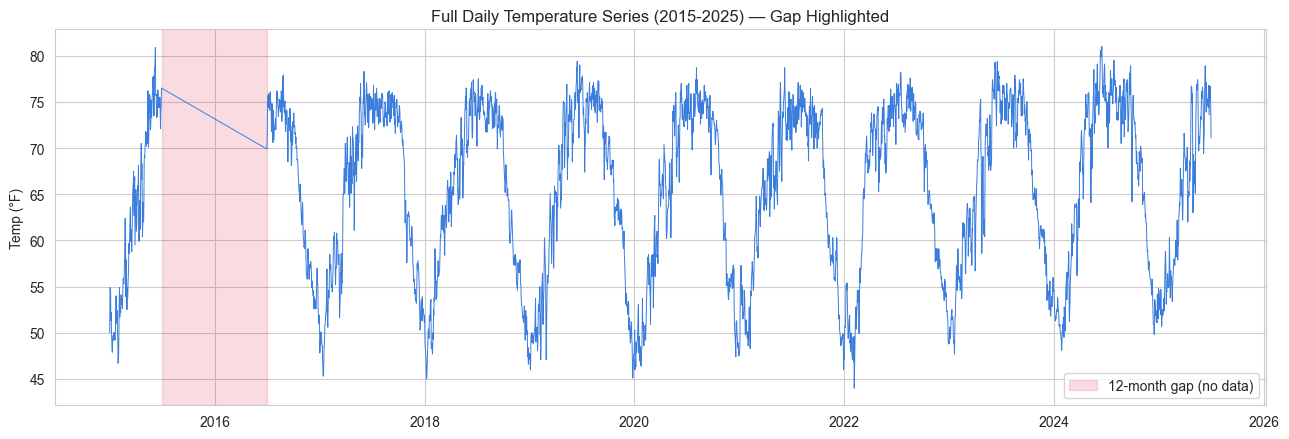


IQR bounds: [32.5, 98.2] °F | Outlier days found: 0


In [21]:
ts_full = df.set_index("datetime")["temp"]

# Gap check
full_range = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="D")
missing_dates = full_range.difference(df["datetime"])
print("Expected days:", len(full_range), "| Present rows:", len(df), "| Missing days:", len(missing_dates))

# Frequency regularity check
diffs = df["datetime"].diff().dropna()
print("\nDay-to-day interval value counts (in days):")
print(diffs.dt.days.value_counts().sort_index())

# Plot
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(ts_full.index, ts_full.values, linewidth=0.7, color="#3b7ddd")
ax.axvspan(pd.Timestamp("2015-07-01"), pd.Timestamp("2016-06-30"), color="crimson", alpha=0.15, label="12-month gap (no data)")
ax.set_title("Full Daily Temperature Series (2015-2025) — Gap Highlighted")
ax.set_ylabel("Temp (°F)")
ax.legend()
plt.tight_layout()
plt.show()

# Outlier check (IQR method) on the temperature series itself
q1, q3 = ts_full.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = ts_full[(ts_full < lower) | (ts_full > upper)]
print(f"\nIQR bounds: [{lower:.1f}, {upper:.1f}] °F | Outlier days found: {len(outliers)}")


**Reading the results:** the series is recorded at a regular **daily** frequency everywhere except the single 12-month block that's fully absent (highlighted in red) — every interval is exactly 1 day except the one 366-day jump, and there are no duplicate/irregular timestamps. The IQR check on the temperature series itself finds **no outliers** — the raw series is smooth and physically bounded, unlike the windspeed/visibility sensor errors found in Part A.

## 24. Seasonality & Trend Decomposition + Autocorrelation Plot (ACF)

In [22]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

ts = df[df["datetime"] >= "2016-07-01"].set_index("datetime")["temp"].asfreq("D")

# STL decomposition
stl = STL(ts, period=365, robust=True)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL Decomposition of Daily Temperature (period=365)", y=1.02)
plt.tight_layout()
plt.show()

# ACF plot
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(ts, lags=400, ax=ax)
ax.set_title("ACF of Daily Temperature (up to 400 lags)")
plt.tight_layout()
plt.show()


TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

**Reading the decomposition:** the **trend** component is close to flat with a slight warming drift over the 9-year window, the **seasonal** component is a clean, repeating annual cycle (confirming the monsoon/winter pattern), and the **residual** is the leftover day-to-day weather noise the LSTM has to predict on top of the seasonal baseline.

**Reading the ACF:** correlation starts near 1.0 at lag 1 and decays gradually — still ~0.77 at lag 30, crosses zero around lag ~90 (quarter-year = most *dissimilar* season), dips to its most negative point around lag ~180 (opposite season), then swings back up to ~0.83 at lag 365 (same time next year). This is the signature of a strongly seasonal series, not a random walk.

## 25. Stationarity Check — Augmented Dickey-Fuller (ADF) Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    stat, pvalue, *rest = adfuller(series.dropna(), autolag="AIC")
    print(f"--- {label} ---")
    print(f"ADF statistic: {stat:.4f}")
    print(f"p-value:       {pvalue:.6f}")
    print(f"Stationary at 5%? {'YES' if pvalue < 0.05 else 'NO'}")
    print()

run_adf(ts, "Raw temperature series")
run_adf(ts.diff(1), "First-order differenced (lag=1)")
run_adf(ts.diff(365), "Seasonally differenced (lag=365)")


--- Raw temperature series ---
ADF statistic: -4.3406
p-value:       0.000378
Stationary at 5%? YES

--- First-order differenced (lag=1) ---
ADF statistic: -8.5525
p-value:       0.000000
Stationary at 5%? YES

--- Seasonally differenced (lag=365) ---
ADF statistic: -10.9649
p-value:       0.000000
Stationary at 5%? YES



/tmp/ipykernel_90/1595030839.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, *rest = adfuller(series.dropna(), autolag="AIC")
/tmp/ipykernel_90/1595030839.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, *rest = adfuller(series.dropna(), autolag="AIC")
/tmp/ipykernel_90/1595030839.py:4: FutureWarning: adfuller currently returns a plain t

**Interpretation:** the ADF test rejects the unit-root null on the **raw series already** (p ≈ 0.0004 < 0.05) — technically "stationary" by this test, because ADF specifically checks for a *stochastic trend/unit root*, not seasonality, and this series has no drifting long-run trend. However, an ADF pass doesn't mean the series is *usable as-is*: the strong seasonal ACF (lag 365 ≈ 0.83) shows the **mean is seasonally-varying**, which will still confuse a model that isn't told what time of year it is. Both first-order and seasonal differencing push the ADF statistic even further into rejection territory, confirming either transform *would* work if strict stationarity were required.

**Transformation decision:** rather than differencing the raw series (which would remove the very seasonal signal the LSTM should learn from), I'll feed the LSTM the **raw temperature values plus the cyclical calendar features already engineered** (`month_sin/cos`, `doy_sin/cos`). This gives the network an explicit signal for "where in the year" each point sits, so it can model the seasonal mean shift itself instead of me removing it beforehand.

## 26. LSTM Window Length — Decision & Justification from the ACF

In [ ]:
from statsmodels.tsa.stattools import acf as acf_fn

acf_vals = acf_fn(ts, nlags=100, fft=True)
for lag in [1, 7, 14, 30, 60, 90]:
    print(f"ACF at lag {lag:>3}: {acf_vals[lag]:.3f}")


ACF at lag   1: 0.985
ACF at lag   7: 0.927
ACF at lag  14: 0.894
ACF at lag  30: 0.769
ACF at lag  60: 0.403
ACF at lag  90: -0.043


**Chosen window length: 14 days.**

Justification from the ACF:
- The ACF is still very high (~0.89) at **lag 14**, meaning a 14-day window sits comfortably in the zone of strong, informative autocorrelation — the network isn't being handed mostly-noise inputs at the edge of the window.
- By **lag 30** the ACF has already fallen to ~0.77 and keeps dropping toward zero near lag ~90, so pushing the window much further doesn't add proportionally useful signal.
- 14 days is also long enough to span typical **synoptic-scale weather systems** (fronts/pressure systems affecting Kathmandu typically evolve over roughly a week), letting the window capture a build-up/reversal pattern rather than a single snapshot.
- I'm **not** extending the window out to the yearly lag (365) even though the ACF rebounds there — that long-range seasonal signal is already supplied directly via the `month_sin/cos` and `doy_sin/cos` features, so the LSTM doesn't need a 365-step lookback to know what season it's in.

**Decision:** use a sliding window of **14 time steps** (14 days of `temp`, `temp_range`, `humidity`, and the cyclical date features) as the LSTM input, predicting the next day's temperature.